In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = './data/'
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

# get the metadata tables
units_table = cache.get_unit_table()
channels_table = cache.get_channel_table()
probes_table = cache.get_probe_table()
behavior_sessions_table = cache.get_behavior_session_table()
ecephys_sessions_table = cache.get_ecephys_session_table()

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.5.0.json. A more up to date version of the dataset -- visual-behavior-ophys_project_manifest_v1.1.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.5.0.json', 'visual-behavior-ophys_project_manifest_v1.1.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-ophys_project_manifest_v1.1.0.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
session_id = 1065437523 #1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Load Relevant Data

In [4]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()
unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))
good_units = unit_channels.loc[good_unit_filter]


# Unit info
unit_indices = np.array(good_units.index)
spike_times = dict([(i,session.spike_times[i]) for i in unit_indices])
structures = dict(good_units.structure_acronym)

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
# Active stimulus
active_stimulus_presentations = stimulus_presentations[stimulus_presentations["active"]]
# Active Stimulus: Time, Name, Is Change
onset_times = active_stimulus_presentations['start_time'].values
image_names = active_stimulus_presentations['image_name'].values
image_is_changes = active_stimulus_presentations['is_change'].values


# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

Pre Compute Bins

In [5]:
first_onset_time = onset_times[0]
last_onset_time = onset_times[-1]

bin_size = 0.05
buffer = 1.5
unit_bin_start_times = np.arange(first_onset_time-buffer, last_onset_time+buffer, bin_size)
unit_bin_end_times = np.arange(first_onset_time+bin_size-buffer, last_onset_time+bin_size+buffer, bin_size)

num_bins = len(unit_bin_start_times)

Get Binned Spike Counts

In [6]:
num_units = len(spike_times)

Y = np.zeros((num_units, num_bins)) # num of neurons, time steps

# For each unit
for k, unit_idx in enumerate(unit_indices):
    # Select corresponding unit's spike times
    unit_spike_times = spike_times[unit_idx]

    # Find the correct indices of the unit spike times for each bin
    start_indices = np.searchsorted(unit_spike_times, unit_bin_start_times)
    stop_indices = np.searchsorted(unit_spike_times, unit_bin_end_times)

    # Get the counts for each bin
    counts = stop_indices - start_indices
    Y[k] = counts

In [7]:
num_inputs = 8 + 1 + 2 + 3 # images, omit, task, behavior

X = np.zeros((num_inputs, num_bins))

Get Images + Omissions

In [8]:
# Getting Images

unique_images = list(np.unique(image_names))

for onset_time,image_name in zip(onset_times, image_names):
    # get image id
    image_id = unique_images.index(image_name)

    # get image time index
    time_idx = np.searchsorted(unit_bin_start_times, onset_time)-1

    X[image_id, time_idx] = 1.0

Get Task

In [9]:
trials = session.trials
trial_start_times = trials.start_time.values
trial_hits = trials.hit.values
trial_misses = trials.miss.values

hit_start_times = trial_start_times[trial_hits]
miss_start_times = trial_start_times[trial_misses]

hit_start_indices = np.searchsorted(hit_start_times, unit_bin_start_times)
hit_stop_indices = np.searchsorted(hit_start_times, unit_bin_end_times)

miss_start_indices = np.searchsorted(miss_start_times, unit_bin_start_times)
miss_stop_indices = np.searchsorted(miss_start_times, unit_bin_end_times)

hit_counts = hit_stop_indices - hit_start_indices
miss_counts = miss_stop_indices - miss_start_indices

X[9] = 1.0*(hit_counts > 0.0)
X[9+1] = 1.0*(miss_counts > 0.0)

Get Behavior

In [10]:
# Running
run_start_indices = np.searchsorted(running_speed.timestamps, unit_bin_start_times)
run_end_indices = np.searchsorted(running_speed.timestamps, unit_bin_end_times)

for time_idx, (run_start_idx, run_end_idx) in enumerate(zip(run_start_indices, run_end_indices)):
    bin_values = running_speed.speed.values[run_start_idx:run_end_idx]
    bin_values = bin_values[~np.isnan(bin_values)]

    # have to include this in case there's not enough values in time frame
    while len(bin_values) < 1:
        run_start_idx -= 1
        run_end_idx += 1
        bin_values = running_speed.speed.values[run_start_idx:run_end_idx]
        bin_values = bin_values[~np.isnan(bin_values)]

    mean_value = np.nanmean(bin_values)
    X[9+2, time_idx] = mean_value

# Pupil
eye_start_indices = np.searchsorted(eye_tracking.timestamps, unit_bin_start_times)
eye_end_indices = np.searchsorted(eye_tracking.timestamps, unit_bin_end_times)

for time_idx, (eye_start_idx, eye_end_idx) in enumerate(zip(eye_start_indices, eye_end_indices)):
    bin_values = eye_tracking.pupil_area.values[eye_start_idx:eye_end_idx]
    bin_values = bin_values[~np.isnan(bin_values)]

    # have to include this in case there's not enough values in time frame
    while len(bin_values) < 1:
        eye_start_idx -= 1
        eye_end_idx += 1
        bin_values = eye_tracking.pupil_area.values[eye_start_idx:eye_end_idx]
        bin_values = bin_values[~np.isnan(bin_values)]

    mean_value = np.nanmean(bin_values)
    X[9+2+1, time_idx] = mean_value


# Licking
start_indices = np.searchsorted(licks.timestamps, unit_bin_start_times)
stop_indices = np.searchsorted(licks.timestamps, unit_bin_end_times)

# Get the counts for each bin
counts = stop_indices - start_indices
X[9+2+2] = 1.0*(counts > 0.0)

In [11]:
# Normalie X and Y
X[9+2+0] = (X[9+2+0]-np.mean(X[9+2+0])) / (np.std(X[9+2+0])+1e-8)# running
X[9+2+1] = (X[9+2+1]-np.mean(X[9+2+1])) / (np.std(X[9+2+1])+1e-8)# pupil
Y = (Y-np.mean(Y, axis=1, keepdims=True)) / (np.std(Y, axis=1, keepdims=True)+1e-8) # spike counts

In [12]:
F, T = X.shape
N, T = Y.shape

In [13]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score

In [14]:
# Create lagged X
tau = 10

X_lag = np.zeros((T - tau, F, (tau + 1)))
for t in range(tau, T):
    window = X[:, t-tau:t+1] # (F, tau+1)
    X_lag[t - tau] = window#.flatten() # (F*(tau+1))

X_lagged = X_lag.reshape(T-tau, -1)
Y_aligned = Y[:, tau:T].T  # shape (T - tau, N)

In [18]:
image_mask = np.zeros(14, dtype=bool)
image_mask[:8] = True

omit_mask = np.zeros(14, dtype=bool)
omit_mask[8] = True

task_mask = np.zeros(14, dtype=bool)
task_mask[9:11] = True

behavior_mask = np.zeros(14, dtype=bool)
behavior_mask[11:15] = True

masks = [image_mask, omit_mask, task_mask, behavior_mask]

per_image_masks = []
for i in range(8):
    per_image_mask = np.zeros(14, dtype=bool)
    per_image_mask[i] = True
    per_image_masks.append(per_image_mask)

In [16]:
masked_scores = []
for mask in masks:
    curr_X_lagged = X_lag[:,~mask].reshape(T-tau, -1)
    # Fit linear model
    model = Ridge(alpha=500.0)
    model.fit(curr_X_lagged, Y_aligned)
    weights = model.coef_

    # Predict Y at same times
    Y_pred_aligned = model.predict(curr_X_lagged)  # shape (T-tau, N)

    mses = np.mean((Y_pred_aligned-Y_aligned)**2, axis=0)
    scores = 1-mses
    masked_scores.append(scores)

In [19]:
image_masked_scores = []
for mask in per_image_masks:
    curr_X_lagged = X_lag[:,~mask].reshape(T-tau, -1)
    # Fit linear model
    model = Ridge(alpha=500.0)
    model.fit(curr_X_lagged, Y_aligned)
    weights = model.coef_

    # Predict Y at same times
    Y_pred_aligned = model.predict(curr_X_lagged)  # shape (T-tau, N)

    mses = np.mean((Y_pred_aligned-Y_aligned)**2, axis=0)
    scores = 1-mses
    image_masked_scores.append(scores)

In [17]:
# Fit linear model
model = Ridge(alpha=500.0)
model.fit(X_lagged, Y_aligned)
weights = model.coef_

# Predict Y at same times
Y_pred_aligned = model.predict(X_lagged)  # shape (T-tau, N)

mses = np.mean((Y_pred_aligned-Y_aligned)**2, axis=0)
scores = 1-mses

In [22]:
noncoding_indices = scores < 0.05
coding_weights = weights[~noncoding_indices]
np.sum(~noncoding_indices)

527

In [23]:
from sklearn.manifold import TSNE

C:\Users\matth\AppData\Local\Temp\ipykernel_11664\2317005097.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


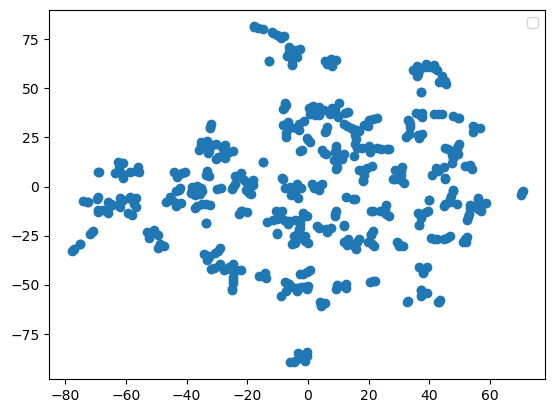

In [48]:
W_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(weights[~noncoding_indices])

plt.scatter(*W_embedded.T[:2])
plt.legend()
plt.show()

In [25]:
import os
os.environ["OMP_NUM_THREADS"] = '4'

from sklearn.cluster import KMeans

In [26]:
K = 8
kmeans = KMeans(n_clusters=K, random_state=1, n_init=10)
clusters = kmeans.fit_predict(coding_weights)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


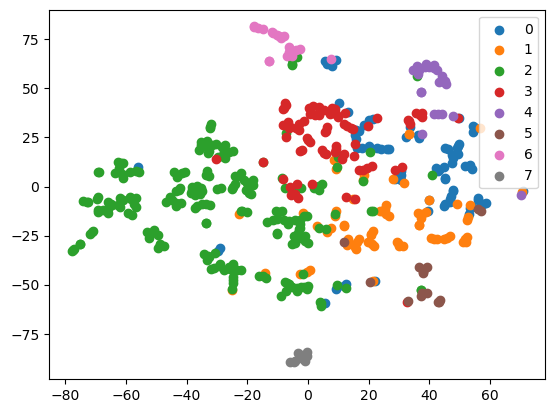

In [49]:
for c in range(np.max(clusters)+1):
    plt.scatter(*W_embedded[:,:2][clusters == c].T, label=c)
plt.legend()
plt.show()

PSTH for Image Flashes

In [28]:
# Set bin size (~10 ms)
bin_size = 0.025
# Set # of bins (~10=100ms=0.1 sec)
num_bins = 20

# Create bin times relative to image onset (0ms, 10ms, 20ms, ..., 90ms)
bins_times_per_onset = np.linspace(0, (num_bins-1)*bin_size, num_bins)

# Create bin start and end times for entire active session
bin_start_times = []
bin_end_times = []

# For each image onset
for onset_time in onset_times:
    # Add bin start and end times
    bin_start_times += list(onset_time + bins_times_per_onset)
    bin_end_times += list(onset_time + bins_times_per_onset + bin_size)

# Convert them to numpy arrays (for efficiency)
bin_start_times = np.array(bin_start_times)
bin_end_times = np.array(bin_end_times)



# Do same for licks
bins_times_per_lick = np.linspace(-bin_size*(num_bins)/2, (num_bins-1)/2 * bin_size, num_bins)


# Create bin start and end times for entire active session
lick_bin_start_times = []
lick_bin_end_times = []

# For each image onset
for onset_time in licks.timestamps.values:
    # Add bin start and end times
    lick_bin_start_times += list(onset_time + bins_times_per_lick)
    lick_bin_end_times += list(onset_time + bins_times_per_lick + bin_size)

# Convert them to numpy arrays (for efficiency)
lick_bin_start_times = np.array(lick_bin_start_times)
lick_bin_end_times = np.array(lick_bin_end_times)

In [ ]:
# Get the # of image flashes and # of units
num_image_flashes = len(onset_times)
num_licks = len(licks.timestamps.values)
num_units = len(spike_times)

# Create data structure for binned spike counts
hist = np.zeros((num_image_flashes, num_bins, num_units))

# For each unit
for k, unit_idx in enumerate(unit_indices):
    # Select corresponding unit's spike times
    unit_spike_times = spike_times[unit_idx]

    # Find the correct indices of the unit spike times for each bin
    start_indices = np.searchsorted(unit_spike_times, bin_start_times)
    stop_indices = np.searchsorted(unit_spike_times, bin_end_times)

    # Get the counts for each bin
    counts = stop_indices - start_indices

    # Store them in our handy-dandy "histogram"
    hist[:,:,k] = counts.reshape(num_image_flashes, num_bins)

In [ ]:
mean_hist = np.mean(hist, axis=0)
coding_means = mean_hist[:,~noncoding_indices]
coding_means = (coding_means - np.mean(coding_means, axis=0, keepdims=True)) / (np.std(coding_means, axis=0, keepdims=True)+1e-6)

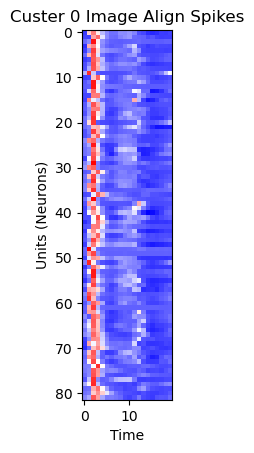

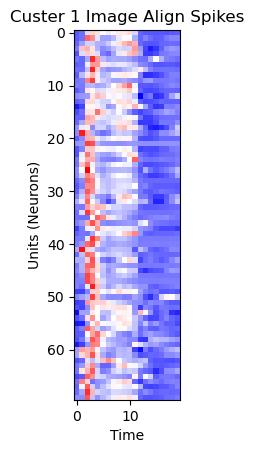

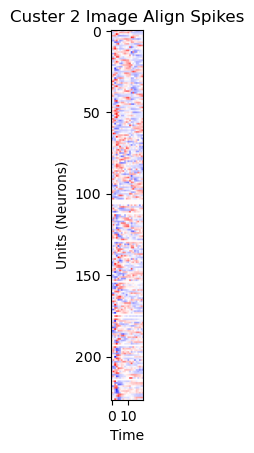

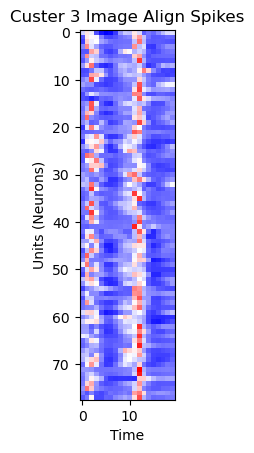

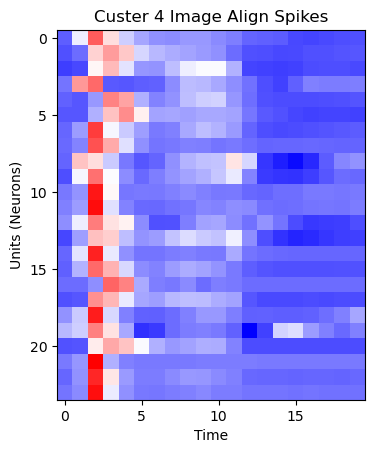

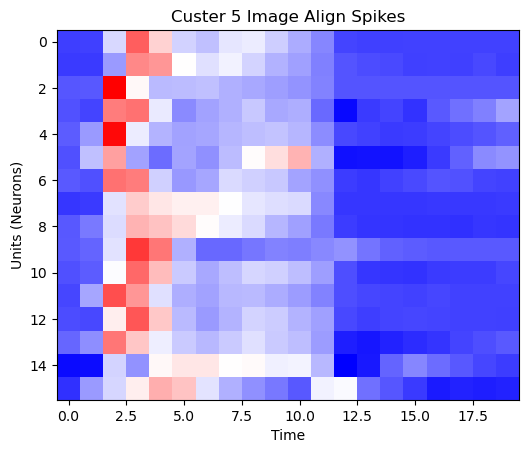

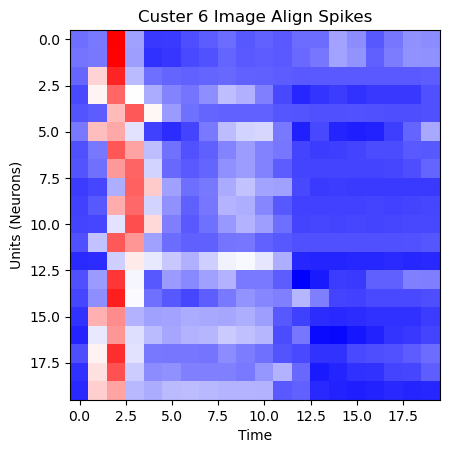

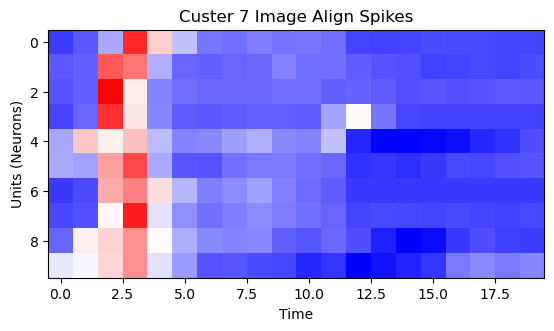

In [47]:
for k in range(K):
    plt.imshow(coding_means[:,clusters == k].T[:], cmap="bwr")
    plt.title(f"Custer {k} Image Align Spikes")
    plt.xlabel("Time")
    plt.ylabel("Units (Neurons)")
    plt.show()

Dropout Scores

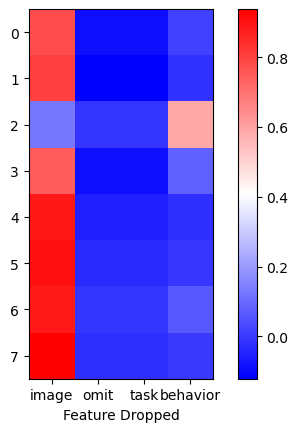

In [33]:
dropout_scores = np.zeros((K, len(masks)))

for k in range(K):
    cluster_indices = clusters==k

    no_drop_score = np.mean(scores[~noncoding_indices][cluster_indices])

    for i in range(len(masks)):
        drop_score = masked_scores[i][~noncoding_indices][cluster_indices]

        dropout_scores[k, i] = (no_drop_score - np.mean(drop_score)) / no_drop_score

plt.imshow(dropout_scores, cmap="bwr")
plt.colorbar()
plt.xticks(ticks=[0,1,2,3], labels=["image", "omit", "task", "behavior"])
plt.xlabel("Feature Dropped")
plt.show()

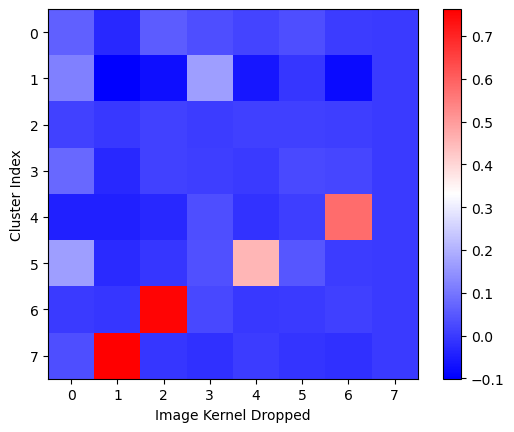

In [ ]:
dropout_scores = np.zeros((K, len(per_image_masks)))

for k in range(K):
    cluster_indices = clusters==k

    no_drop_score = np.mean(scores[~noncoding_indices][cluster_indices])

    for i in range(len(per_image_masks)):
        drop_score = image_masked_scores[i][~noncoding_indices][cluster_indices]

        dropout_scores[k, i] = (no_drop_score - np.mean(drop_score)) / no_drop_score

plt.imshow(dropout_scores, cmap="bwr")
plt.colorbar()
#plt.xticks(ticks=[0,1,2,3], labels=np.arange(8))
plt.xlabel("Image Kernel Dropped")
plt.ylabel("Cluster Index")
plt.show()